In [1]:
######################## 1

In [2]:
import pandas as pd
import scipy.stats as st
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
#from scipy.stats import t
from scipy.stats import ttest_ind, mannwhitneyu

In [4]:
# all_df = pd.read_excel('Диплом датасет.xlsx', sheet_name = None)

all_df = pd.read_excel('Новый датасет.xlsx', sheet_name = None)

# 
df_dt = all_df['Данные']
df_cl = all_df['Clients']
df_reg = all_df['Region_dict']

In [5]:
df_dt

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-10-28 04:05:15.221
1,100242,191056.0,4151.0,2022-08-01 02:42:54.992
2,100249,200049.0,5688.0,2022-08-24 12:45:12.744
3,100258,206161.0,4330.0,2022-12-09 15:13:26.437
4,100267,190945.0,5488.0,2022-08-03 02:07:31.468
...,...,...,...,...
37984,297586,NaN,NaN,NaT
37985,297593,179230.0,5755.0,2022-09-05 03:29:07.726
37986,297595,192530.0,4448.0,2022-09-27 23:50:05.734
37987,297601,183888.0,1746.0,2022-10-13 14:23:03.073


In [6]:
print(df_dt.isna().sum())

id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64


In [7]:
df_dt.dropna(inplace = True)

In [8]:
print(df_reg.isna().sum())

id_trading_point    0
city                0
dtype: int64


In [9]:
df_cl.dropna(inplace = True)

In [10]:
print(df_cl.isna().sum())

id_client           0
dtime_ad            0
nflag_test          0
id_trading_point    0
dtype: int64


In [11]:
df_cl.reset_index()

,index,id_client,dtime_ad,nflag_test,id_trading_point
0,0,180844,2022-06-08 18:38:41.414,0,212
1,2,226069,2022-07-11 16:28:38.511,1,54
2,3,183981,2022-06-16 12:23:59.289,1,991
3,4,322530,2022-07-08 08:56:08.714,0,1015
4,5,254313,2022-06-19 22:18:01.770,1,453
...,...,...,...,...,...
55351,55600,193038,2022-07-09 00:31:25.196,0,1015
55352,55601,244069,2022-08-08 00:12:31.319,1,991
55353,55602,189084,2022-06-29 04:34:42.610,1,439
55354,55603,182758,2022-06-13 11:28:37.856,1,573


In [12]:
df_reg

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир
...,...,...
61,3987,Москва
62,6543,Москва
63,8543,Москва
64,9121,Москва


In [13]:
df_reg_gr = df_reg.groupby('city')['id_trading_point'].count()
df_reg_gr

city
Великий Новгород     1
Владимир             1
Волгоград            1
Дмитров              1
Казань               6
Краснодар            4
Красноярск           5
Москва              11
Мурманск             2
Нижний Новгород      1
Новосибирск          6
Петрозаводск         1
Ростов Великий       1
Ростов-на-Дону       1
Самара               4
Санкт-Петербург     11
Саратов              2
Сахалинск            1
Сочи                 2
Тольятти             1
Тюмень               1
Чехов                1
Ярославль            1
Name: id_trading_point, dtype: int64

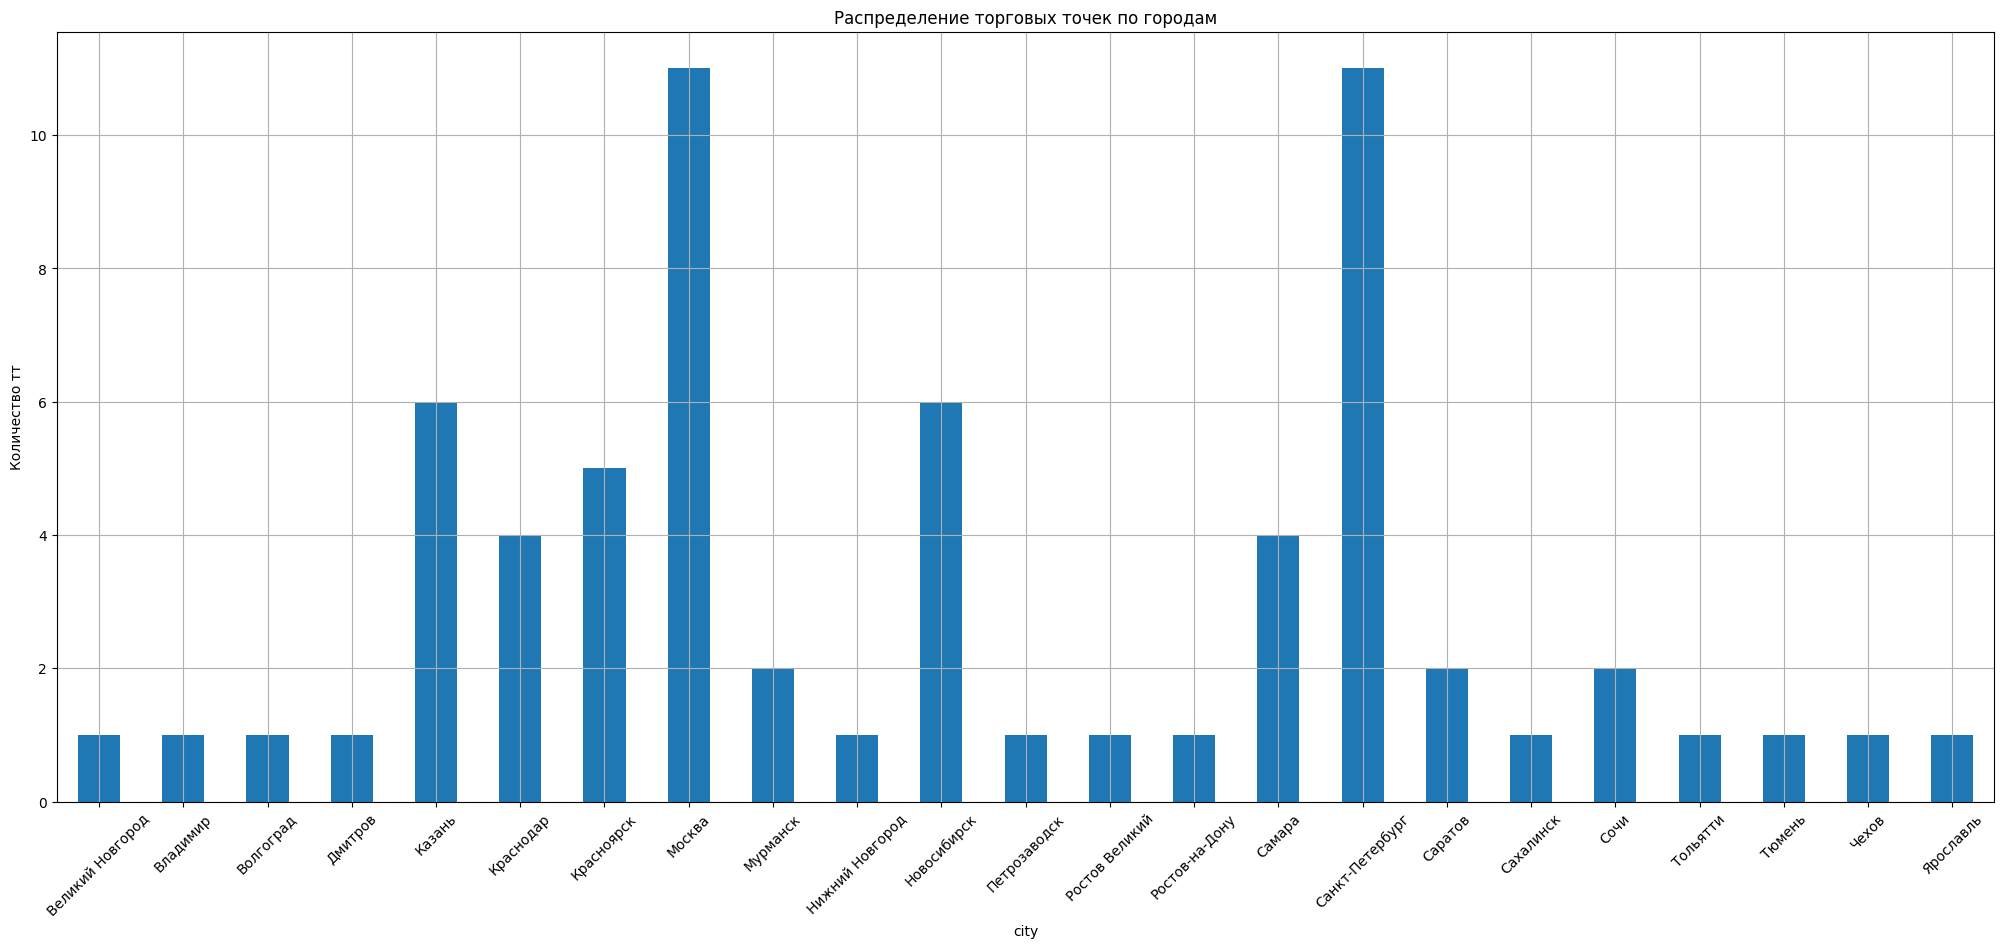

In [14]:
df_reg_gr.plot(kind = 'bar', figsize = (25, 10), y = 'id_trading_point', x = 'city', ylabel = 'Количество тт', grid = True, title = 'Распределение торговых точек по городам')
plt.xticks(rotation = 45)
plt.show()

In [15]:
######################## 2

In [16]:
df_dt.reset_index()

,index,id_order,id_client,amt_payment,dtime_pay
0,0,100238,194569.0,5373.0,2022-10-28 04:05:15.221
1,1,100242,191056.0,4151.0,2022-08-01 02:42:54.992
2,2,100249,200049.0,5688.0,2022-08-24 12:45:12.744
3,3,100258,206161.0,4330.0,2022-12-09 15:13:26.437
4,4,100267,190945.0,5488.0,2022-08-03 02:07:31.468
...,...,...,...,...,...
35555,37983,297572,195257.0,2191.0,2022-08-21 18:31:51.585
35556,37985,297593,179230.0,5755.0,2022-09-05 03:29:07.726
35557,37986,297595,192530.0,4448.0,2022-09-27 23:50:05.734
35558,37987,297601,183888.0,1746.0,2022-10-13 14:23:03.073


In [17]:
df_dt_gr = df_dt.groupby('id_client')[['amt_payment']].sum().reset_index()
df_dt_gr.shape

(28383, 2)

In [18]:
df_cl.shape

(55356, 4)

In [19]:
df2 = df_dt_gr.merge(df_cl, on = 'id_client', how = 'right')
df2.shape

(55356, 5)

In [20]:
df2.head()

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212
1,226069.0,NaN,2022-07-11 16:28:38.511,1,54
2,183981.0,6322.0,2022-06-16 12:23:59.289,1,991
3,322530.0,NaN,2022-07-08 08:56:08.714,0,1015
4,254313.0,NaN,2022-06-19 22:18:01.770,1,453


In [21]:
df2['amt_payment'] = df2['amt_payment'].fillna(0)
df2.head()

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212
1,226069.0,0.0,2022-07-11 16:28:38.511,1,54
2,183981.0,6322.0,2022-06-16 12:23:59.289,1,991
3,322530.0,0.0,2022-07-08 08:56:08.714,0,1015
4,254313.0,0.0,2022-06-19 22:18:01.770,1,453


In [22]:
df3 = df2.merge(df_reg, on = 'id_trading_point', how = 'inner')
df3.head()

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск
1,223863.0,0.0,2022-08-20 21:56:54.325,0,212,Красноярск
2,201715.0,4171.0,2022-07-30 19:07:49.264,1,212,Красноярск
3,292010.0,0.0,2022-07-26 20:37:16.885,1,212,Красноярск
4,190438.0,6026.0,2022-07-02 12:53:04.753,1,212,Красноярск


In [23]:
df3['fl_p'] = np.where(df3['amt_payment'] == 0, 0, 1)

In [37]:
df3

,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city,fl_p
0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск,1
1,223863.0,0.0,2022-08-20 21:56:54.325,0,212,Красноярск,0
2,201715.0,4171.0,2022-07-30 19:07:49.264,1,212,Красноярск,1
3,292010.0,0.0,2022-07-26 20:37:16.885,1,212,Красноярск,0
4,190438.0,6026.0,2022-07-02 12:53:04.753,1,212,Красноярск,1
...,...,...,...,...,...,...,...
55351,321313.0,0.0,2022-06-17 15:42:47.009,1,1002,Москва,0
55352,200856.0,6696.0,2022-07-28 14:51:08.149,1,1002,Москва,1
55353,198305.0,3901.0,2022-07-22 06:24:33.232,0,1002,Москва,1
55354,201820.0,0.0,2022-07-31 01:25:03.638,0,1002,Москва,0


In [26]:
######################## 3

In [27]:
def test_calc(r1, r2, pvalue = 0.05):
    print('разница между средними значениями:', r1.mean() - r2.mean())
    s_s, p = ttest_ind(r1, r2)
    if p < pvalue:
        print('Гипотеза отвергается, разница стат. значима')
    else:
        print('Гипотеза не отвергается, средние равны')
    return s_s, p

In [31]:
# test_calc(df3[df3['nflag_test'] == 0]['amt_payment'], df3[df3['nflag_test'] == 1]['amt_payment'])

In [29]:
def mann_whitney_func(r1, r2, pvalue = 0.05):
    print('разница между средними значениями:', r1.mean() - r2.mean())
    mw_s, p = mannwhitneyu(x = r1, y = r2)
    if p < pvalue:
        print('Гипотеза отвергается, разница стат. значима')
    else:
        print('Гипотеза не отвергается, средние равны')
    return mw_s, p

In [32]:
# mann_whitney_func(df3[df3['nflag_test'] == 0]['amt_payment'], df3[df3['nflag_test'] == 1]['amt_payment'])

In [33]:
######################## 4

In [40]:
# free_lst1 = []
# for i in df3['id_trading_point'].unique():
#     if ((df3[(df3['id_trading_point'] == i) & (df3['nflag_test'] == 0)]['amt_payment'].sum()) == 0) | ((df3[(df3['id_trading_point'] == i) & (df3['nflag_test'] == 1)]['amt_payment'].sum()) == 1):
#         free_lst1.append(i)
# free_lst1 = [int(x1) for x1 in free_lst1]
# print(free_lst1)

free_lst1 = []

for i in df3['id_trading_point'].unique():
    
    df_loc = df3[df3['id_trading_point'] == i]
    
    if (df_loc[df_loc['nflag_test'] == 0]['amt_payment'].sum() == 0) | (df_loc[df_loc['nflag_test'] == 1]['amt_payment'].sum() == 0):
            free_lst1.append(i)
        
print(free_lst1)

[1015, 866, 1099, 739, 46, 228, 26, 603, 810, 800, 7, 23, 4, 1, 13]


In [42]:
# free_lst2 = []
# for j in df3['id_trading_point'].unique():
#     if ((df3[(df3['id_trading_point'] == j) & (df3['nflag_test'] == 0)].count()['id_client']) == 0) | ((df3[(df3['id_trading_point'] == j) & (df3['nflag_test'] == 1)].count()['id_client']) == 0):
#         free_lst2.append(j)
# free_lst2 = [int(y1) for y1 in free_lst2]
# print(free_lst2)

free_lst2 = []

for i in df3['id_trading_point'].unique():
    
    df_loc = df3[df3['id_trading_point'] == i]
    
    if (df_loc[df_loc['nflag_test'] == 0]['id_client'].count() == 0) | (df_loc[df_loc['nflag_test'] == 1]['id_client'].count() == 0):
            free_lst2.append(i)
        
print(free_lst2)

[1015, 866, 1099, 739, 228, 603, 810, 800]


In [43]:
######################## 5

In [44]:
cl_df3 = df3[~df3['id_trading_point'].isin(free_lst1 + free_lst2)].reset_index()
cl_df3

,index,id_client,amt_payment,dtime_ad,nflag_test,id_trading_point,city,fl_p
0,0,180844.0,5349.0,2022-06-08 18:38:41.414,0,212,Красноярск,1
1,1,223863.0,0.0,2022-08-20 21:56:54.325,0,212,Красноярск,0
2,2,201715.0,4171.0,2022-07-30 19:07:49.264,1,212,Красноярск,1
3,3,292010.0,0.0,2022-07-26 20:37:16.885,1,212,Красноярск,0
4,4,190438.0,6026.0,2022-07-02 12:53:04.753,1,212,Красноярск,1
...,...,...,...,...,...,...,...,...
45313,55351,321313.0,0.0,2022-06-17 15:42:47.009,1,1002,Москва,0
45314,55352,200856.0,6696.0,2022-07-28 14:51:08.149,1,1002,Москва,1
45315,55353,198305.0,3901.0,2022-07-22 06:24:33.232,0,1002,Москва,1
45316,55354,201820.0,0.0,2022-07-31 01:25:03.638,0,1002,Москва,0


In [48]:
vz_df3 = cl_df3[(cl_df3['amt_payment'] != 0) & (cl_df3['amt_payment'] < 15000)].reset_index()

In [49]:
#sns.displot(cl_df3[(cl_df3['amt_payment'] != 0) & (cl_df3['amt_payment'] < 15000)], x = 'amt_payment', hue = 'nflag_test')
#plt.show()

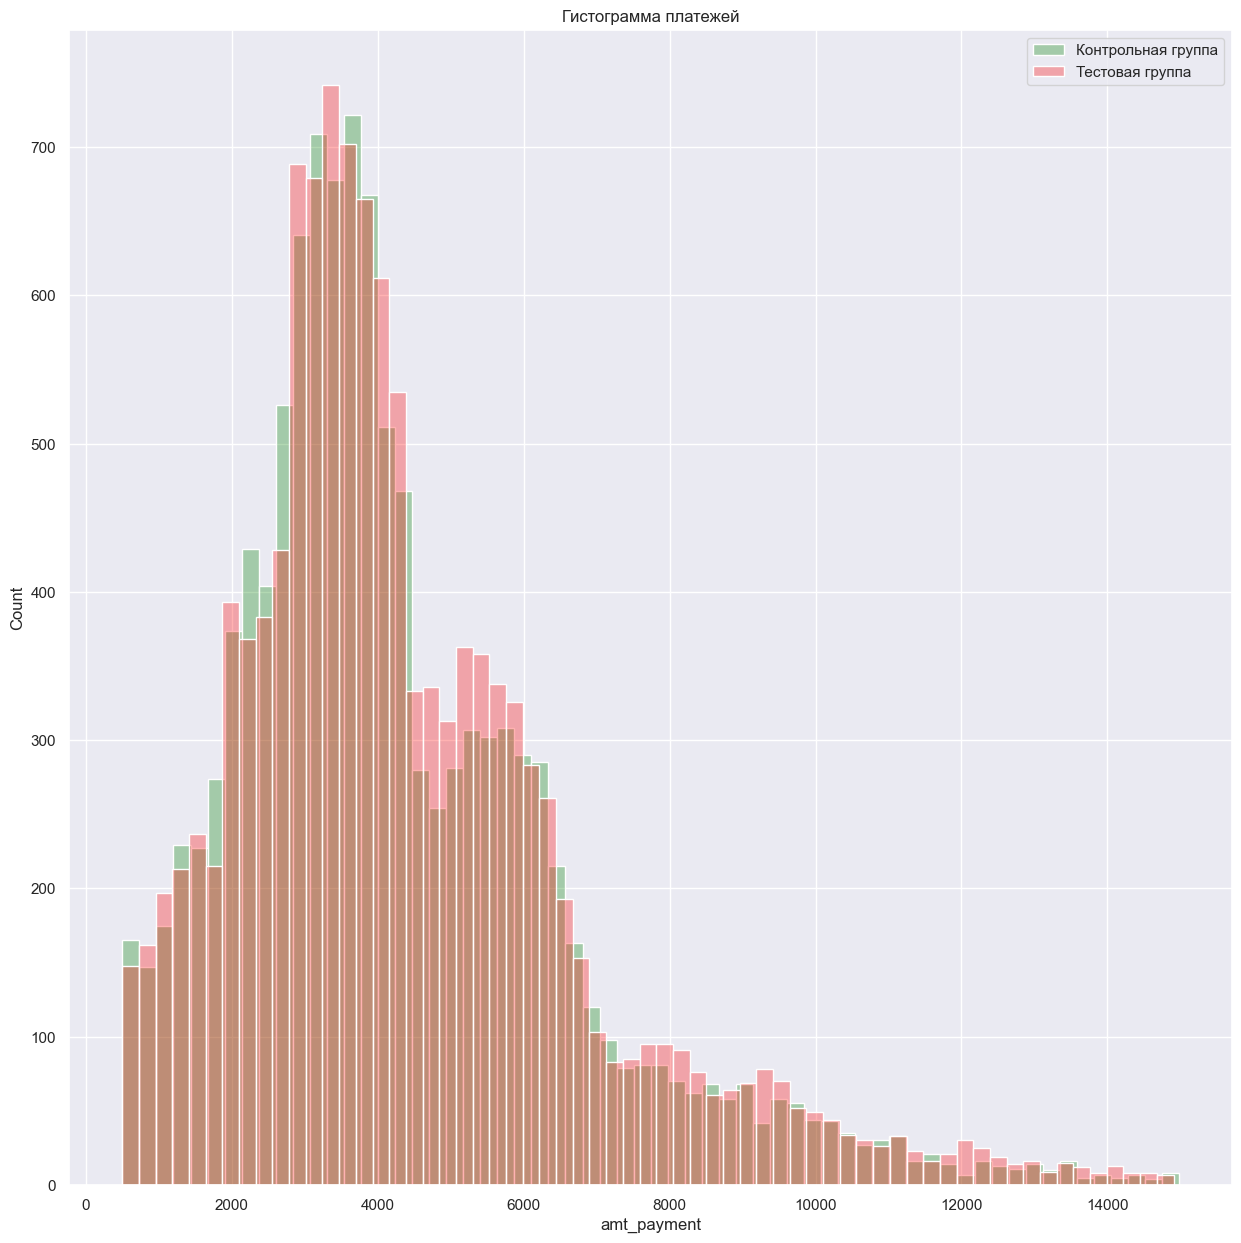

In [50]:
sns.set(rc = {'figure.figsize':(15,15)})
sns.histplot(vz_df3[vz_df3['nflag_test'] == 0]['amt_payment'].reset_index(), x = "amt_payment", label = "Контрольная группа", color = 'green', alpha = .3)
sns.histplot(vz_df3[vz_df3['nflag_test'] == 1]['amt_payment'].reset_index(), x = "amt_payment", label = "Тестовая группа", color = 'red', alpha = .3)
plt.title('Гистограмма платежей')
plt.legend()
plt.show()

In [51]:
test_calc(cl_df3[cl_df3['nflag_test'] == 0]['amt_payment'], cl_df3[cl_df3['nflag_test'] == 1]['amt_payment'])

разница между средними значениями: -263.088912844727
Гипотеза отвергается, разница стат. значима


(-9.456798235171377, 3.3214645838934018e-21)

In [52]:
test_calc(cl_df3[cl_df3['nflag_test'] == 0]['fl_p'], cl_df3[cl_df3['nflag_test'] == 1]['fl_p'])

разница между средними значениями: -0.043524040271688325
Гипотеза отвергается, разница стат. значима


(-9.282032730948323, 1.7338073027564523e-20)

In [53]:
mann_whitney_func(cl_df3[cl_df3['nflag_test'] == 0]['amt_payment'], cl_df3[cl_df3['nflag_test'] == 1]['amt_payment'])

разница между средними значениями: -263.088912844727
Гипотеза отвергается, разница стат. значима


(243344369.0, 3.008345273971901e-24)

In [54]:
#mann_whitney_func(cl_df3[cl_df3['nflag_test'] == 0]['fl_p'], cl_df3[cl_df3['nflag_test'] == 1]['fl_p'])

In [55]:
######################## 6



Красноярск
разница между средними значениями: -8.718297889251062
Гипотеза не отвергается, средние равны
разница между средними значениями: 0.003592020255924089
Гипотеза не отвергается, средние равны
разница между средними значениями: -8.718297889251062
Гипотеза не отвергается, средние равны


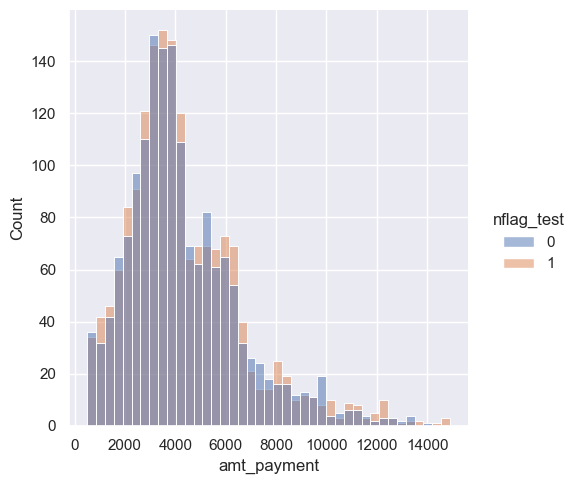



Мурманск
разница между средними значениями: -8.051371737534055
Гипотеза не отвергается, средние равны
разница между средними значениями: -0.018187481921545068
Гипотеза не отвергается, средние равны
разница между средними значениями: -8.051371737534055
Гипотеза не отвергается, средние равны


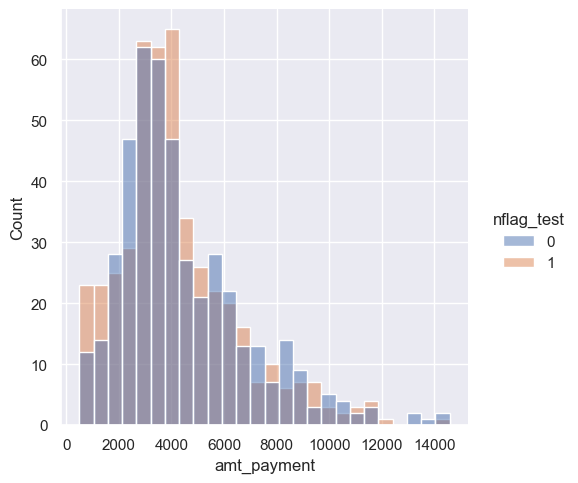



Казань
разница между средними значениями: -121.22480263872694
Гипотеза не отвергается, средние равны
разница между средними значениями: -0.003829103608847473
Гипотеза не отвергается, средние равны
разница между средними значениями: -121.22480263872694
Гипотеза не отвергается, средние равны


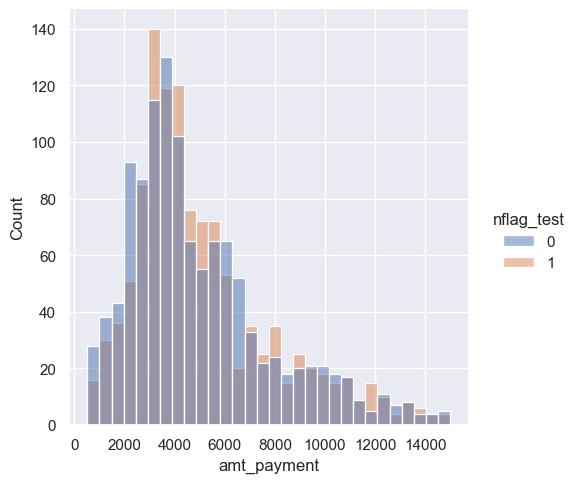



Санкт-Петербург
разница между средними значениями: -513.9039043833998
Гипотеза отвергается, разница стат. значима
разница между средними значениями: -0.09877797751600403
Гипотеза отвергается, разница стат. значима
разница между средними значениями: -513.9039043833998
Гипотеза отвергается, разница стат. значима


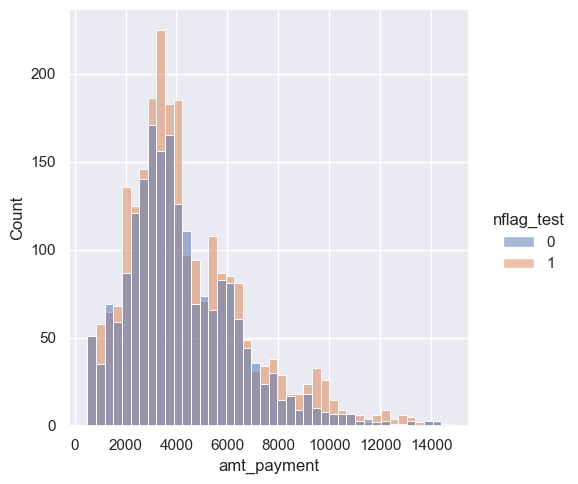



Москва
разница между средними значениями: -381.7784892750842
Гипотеза отвергается, разница стат. значима
разница между средними значениями: -0.05557800593933432
Гипотеза отвергается, разница стат. значима
разница между средними значениями: -381.7784892750842
Гипотеза отвергается, разница стат. значима


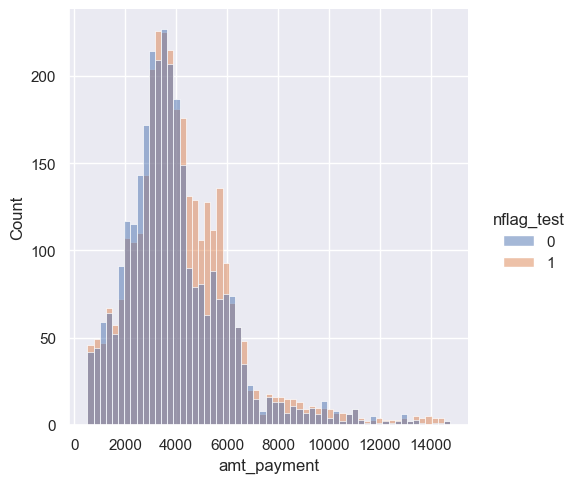



Саратов
разница между средними значениями: 12.85688039258821
Гипотеза не отвергается, средние равны
разница между средними значениями: -0.013960087839155033
Гипотеза не отвергается, средние равны
разница между средними значениями: 12.85688039258821
Гипотеза не отвергается, средние равны


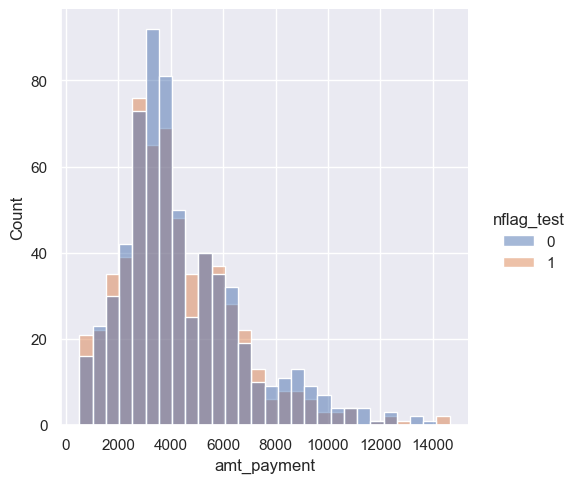



Тольятти
разница между средними значениями: -462.9494484714778
Гипотеза не отвергается, средние равны
разница между средними значениями: -0.061266939804601295
Гипотеза не отвергается, средние равны
разница между средними значениями: -462.9494484714778
Гипотеза не отвергается, средние равны


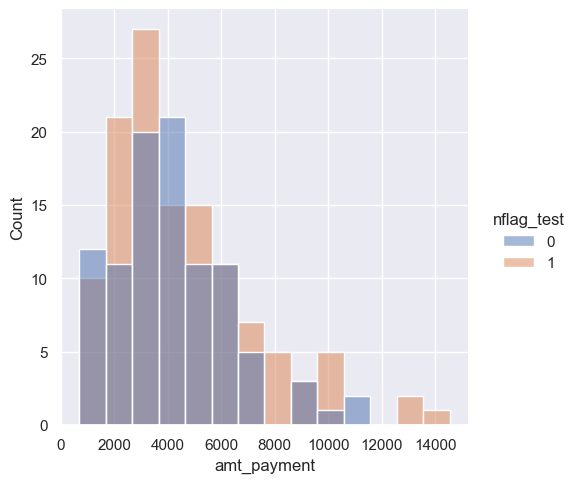



Тюмень
разница между средними значениями: -300.4463645943099
Гипотеза не отвергается, средние равны
разница между средними значениями: -0.1463645943097998
Гипотеза отвергается, разница стат. значима
разница между средними значениями: -300.4463645943099
Гипотеза отвергается, разница стат. значима


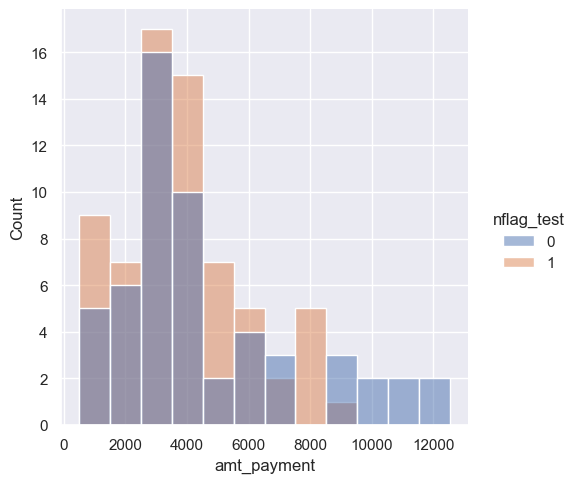



Волгоград
разница между средними значениями: 312.89040013337035
Гипотеза отвергается, разница стат. значима
разница между средними значениями: 0.04350565417616603
Гипотеза не отвергается, средние равны
разница между средними значениями: 312.89040013337035
Гипотеза отвергается, разница стат. значима


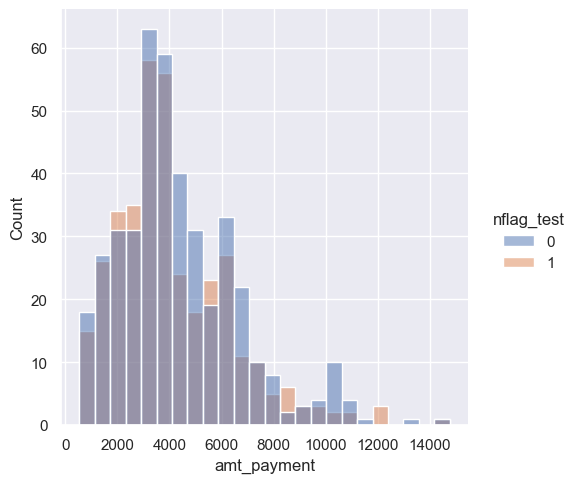



Сочи
разница между средними значениями: 217.2514838460288
Гипотеза не отвергается, средние равны
разница между средними значениями: 0.04931605920420967
Гипотеза отвергается, разница стат. значима
разница между средними значениями: 217.2514838460288
Гипотеза не отвергается, средние равны


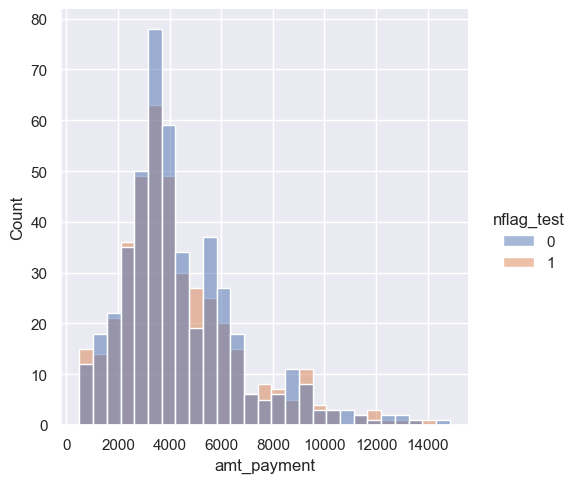



Владимир
разница между средними значениями: -438.6098419243094
Гипотеза отвергается, разница стат. значима
разница между средними значениями: -0.05174296866921729
Гипотеза не отвергается, средние равны
разница между средними значениями: -438.6098419243094
Гипотеза отвергается, разница стат. значима


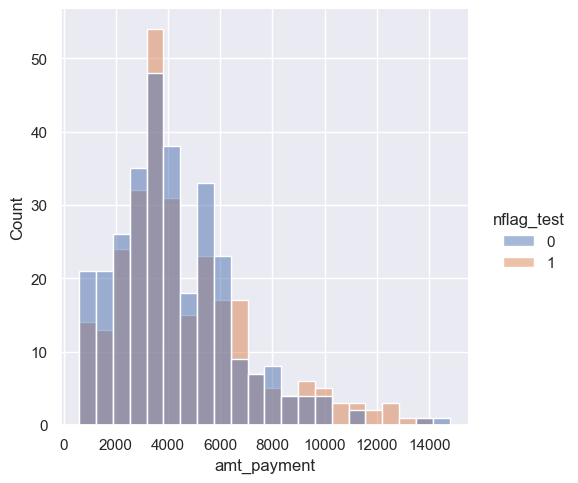



Самара
разница между средними значениями: -1544.3720191247648
Гипотеза отвергается, разница стат. значима
разница между средними значениями: -0.2772412939282998
Гипотеза отвергается, разница стат. значима
разница между средними значениями: -1544.3720191247648
Гипотеза отвергается, разница стат. значима


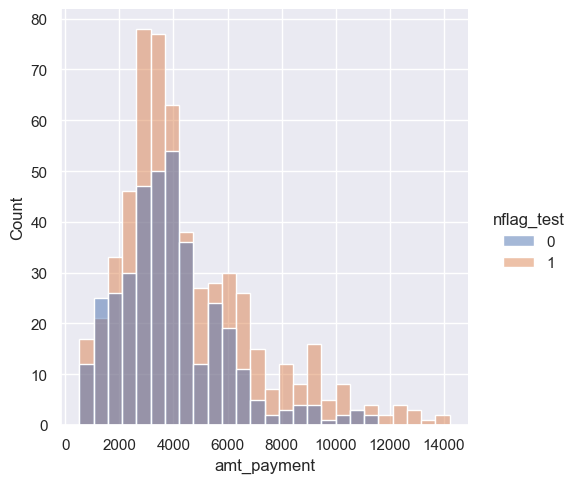



Краснодар
разница между средними значениями: 215.62639239464443
Гипотеза не отвергается, средние равны
разница между средними значениями: 0.03894675290825289
Гипотеза не отвергается, средние равны
разница между средними значениями: 215.62639239464443
Гипотеза не отвергается, средние равны


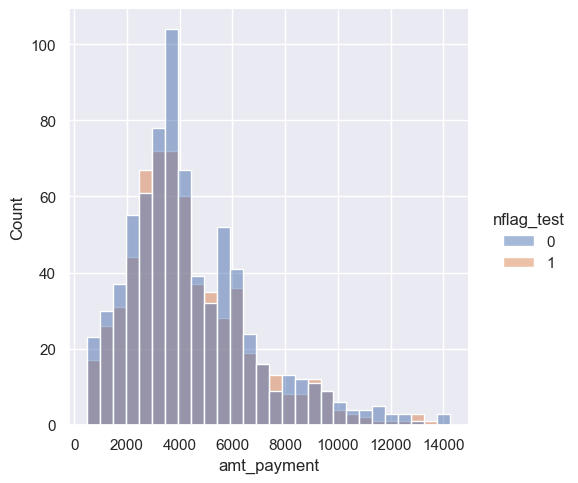



Сахалинск
разница между средними значениями: -571.2994871794872
Гипотеза не отвергается, средние равны
разница между средними значениями: -0.07230769230769232
Гипотеза не отвергается, средние равны
разница между средними значениями: -571.2994871794872
Гипотеза не отвергается, средние равны


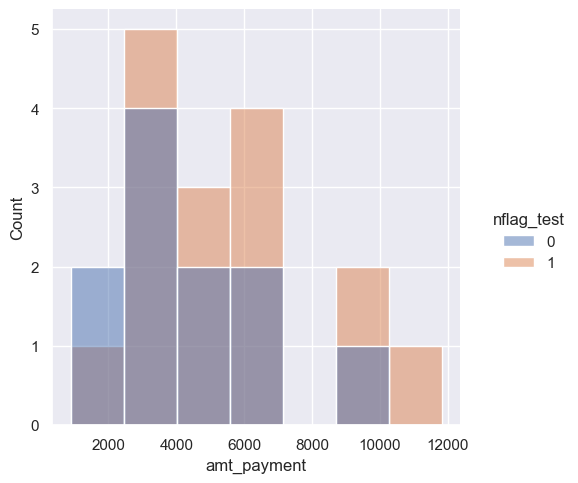



Дмитров
разница между средними значениями: -95.88262910798124
Гипотеза не отвергается, средние равны
разница между средними значениями: -0.01679306608884075
Гипотеза не отвергается, средние равны
разница между средними значениями: -95.88262910798124
Гипотеза не отвергается, средние равны


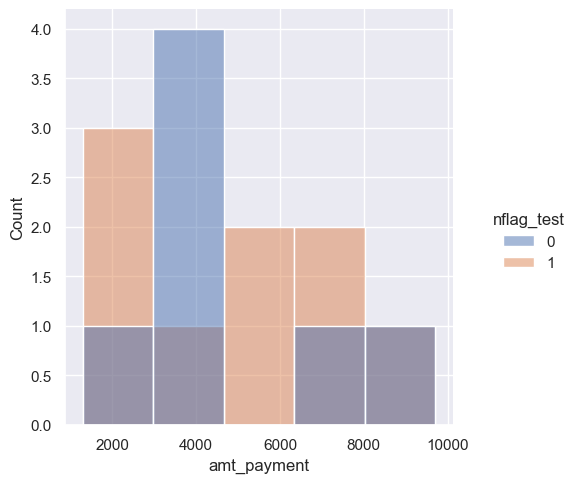

In [56]:
for i in cl_df3['city'].unique():
    print('\n')
    print(i)
    cl_df3_c = cl_df3[cl_df3['city'] == i]  
    test_calc(cl_df3_c[cl_df3_c['nflag_test'] == 0]['amt_payment'], cl_df3_c[cl_df3_c['nflag_test'] == 1]['amt_payment'])
    test_calc(cl_df3_c[cl_df3_c['nflag_test'] == 0]['fl_p'], cl_df3_c[cl_df3_c['nflag_test'] == 1]['fl_p'])
    mann_whitney_func(cl_df3_c[cl_df3_c['nflag_test'] == 0]['amt_payment'], cl_df3_c[cl_df3_c['nflag_test'] == 1]['amt_payment'])
    #mann_whitney_func(cl_df3_c[cl_df3_c['nflag_test'] == 0]['fl_p'], cl_df3_c[cl_df3_c['nflag_test'] == 1]['fl_p'])
    sns.displot(cl_df3_c[(cl_df3_c['amt_payment'] != 0) & (cl_df3_c['amt_payment'] < 15000)], x = 'amt_payment', hue = 'nflag_test')
    plt.show()

In [57]:
######################## 7

In [58]:
results = pd.DataFrame()
for i in cl_df3['city'].unique():
    city_df = cl_df3[cl_df3['city'] == i]
    for j in city_df['id_trading_point'].unique():
        tt_df =  city_df[city_df['id_trading_point'] == j]
        count_test = len(tt_df[tt_df['nflag_test'] == 1])
        count_control = len(tt_df[tt_df['nflag_test'] == 0])
        count_all = count_test + count_control
        percent_count = count_all / len(cl_df3)
        avg_payment_test = tt_df[tt_df['nflag_test'] == 1]['amt_payment'].mean()
        avg_payment_control = tt_df[tt_df['nflag_test'] == 0]['amt_payment'].mean()
        diff = avg_payment_test - avg_payment_control
        sigma_test = tt_df[tt_df['nflag_test'] == 1]['amt_payment'].std()
        sigma_control = tt_df[tt_df['nflag_test'] == 0]['amt_payment'].std()
        s, p = ttest_ind(tt_df[tt_df['nflag_test'] == 0]['amt_payment'], tt_df[tt_df['nflag_test'] == 1]['amt_payment'])
        ttest = s
        pvalue_ttest = p
        if diff > 0 and p < 0.05:
            label = 'Положительный исход'
        elif diff < 0 and p < 0.05: 
            label = 'Отрицательный исход'
        elif p > 0.05: 
            label ='Нейтральный исход' 
        else: 'Неопределенный исход'
        new_row = pd.DataFrame([{'city': i, 'id_trading_point': j, 'count_test': count_test, 'count_control': count_control, 'count_all': count_all, 'percent_count': percent_count, 'avg_payment_test': avg_payment_test, 'avg_payment_control': avg_payment_control, 'diff': diff, 'sigma_test': sigma_test, 'sigma_control': sigma_control, 'ttest': ttest, 'pvalue_ttest': pvalue_ttest, 'label': label}])     
        results = pd.concat([results, new_row], ignore_index = True)
        #print(i)
        #results._append({'city': i, 'id_trading_point': j, 'count_test': count_test, 'count_control': count_control, 'count_all': count_all, 'percent_count': percent_count, 'avg_payment_test': avg_payment_test, 'avg_payment_control': avg_payment_control, 'diff': diff, 'sigma_test': sigma_test, 'sigma_control': sigma_control, 'ttest': ttest, 'pvalue_ttest': pvalue_ttest, 'label': label}, ignore_index = True)
                    
#df_fin = pd.DataFrame(results)



In [59]:
results.head(30) 

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,label
0,Красноярск,212,593,575,1168,0.025773,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,0.483585,6.287709e-01,Нейтральный исход
1,Красноярск,278,535,489,1024,0.022596,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,-1.820268,6.901056e-02,Нейтральный исход
2,Красноярск,202,551,565,1116,0.024626,2927.341198,2730.378761,196.962437,2956.686241,2737.885785,-1.155073,2.483083e-01,Нейтральный исход
3,Красноярск,444,650,562,1212,0.026744,2404.106154,2545.734875,-141.628722,2810.828487,2797.138764,0.876740,3.808017e-01,Нейтральный исход
4,Красноярск,277,708,709,1417,0.031268,2285.750000,2431.365303,-145.615303,2712.677878,2868.587569,0.981705,3.264128e-01,Нейтральный исход
5,Мурманск,54,633,640,1273,0.028090,1702.714060,1688.512500,14.201560,2565.132440,2628.012490,-0.097556,9.223005e-01,Нейтральный исход
6,Мурманск,55,422,425,847,0.018690,2109.106635,2111.272941,-2.166306,2790.993385,2804.223188,0.011268,9.910125e-01,Нейтральный исход
7,Казань,991,270,294,564,0.012445,3249.281481,2452.986395,796.295087,4719.592601,3633.935858,-2.255258,2.450100e-02,Положительный исход
8,Казань,699,482,494,976,0.021537,2422.286307,2574.352227,-152.065920,3906.817897,4082.851356,0.594254,5.524804e-01,Нейтральный исход
9,Казань,477,382,386,768,0.016947,2259.623037,2496.987047,-237.364010,3482.846094,3881.994719,0.891593,3.728909e-01,Нейтральный исход


In [60]:
results['label'].value_counts()

Нейтральный исход      31
Положительный исход    17
Отрицательный исход     3
Name: label, dtype: int64

In [61]:
results[results['label'] == 'Отрицательный исход']

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,label
32,Москва,9931,153,137,290,0.006399,1415.784314,1968.693431,-552.909117,2038.164247,2403.397857,2.119197,0.034929,Отрицательный исход
39,Волгоград,66,657,703,1360,0.030010,2288.870624,2601.761024,-312.890400,2682.567610,2830.193773,2.089272,0.036869,Отрицательный исход
47,Краснодар,1101,785,869,1654,0.036498,2176.003822,2523.578826,-347.575005,2722.624494,2960.352338,2.476736,0.013358,Отрицательный исход
